### **Estimating and Predicting Extant Avian Mass using Ordinary Least Squares Regression**

Dataset sourced from the Vertebrate Zoology collection of the Yale Peabody Museum

In [45]:
#Import the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error)
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

#### **1. Data Preparation and Exporatory Data Analysis**

In [46]:
bird_df = pd.read_csv('pone.0082000.s003.csv')

print(bird_df.to_string())

                 Order           Genus          species  Specimen number (YPM) sex  mass (g)  femur_circumference (mm)  femur_diamter (mm)  femur_length (mm)  humerus_diameter (mm)  humerus_length (mm)  tarsus_circumference (mm)  tarsus_diameter (mm)  tarsus_length (mm)  tibia_length (mm)  humerus_circumference (mm)  coracoid HAF (mm)  coracoid shaft width  coracoid max length
0      Accipitriformes       Accipiter         cooperii                 109131   m     349.0                     15.98                5.16              60.69                   5.30                57.83                      10.38                  3.50               66.58              82.72                       16.45               4.77                  3.49                35.42
1      Accipitriformes       Accipiter         cooperii                 104408   m     349.0                     15.52                4.94              53.89                   4.73                72.76                      13.07            

In [47]:
print(bird_df.describe().round(2).transpose().to_string())

                            count       mean      std      min        25%        50%        75%        max
Specimen number (YPM)       863.0  107503.17  9057.07  2103.00  105196.50  109015.00  110654.00  142576.00
mass (g)                    863.0     619.78  1065.88     2.90      41.25     180.00     810.00    9670.00
femur_circumference (mm)    863.0      11.68     8.15     1.35       4.85       9.35      16.34      49.15
femur_diamter (mm)          863.0       3.49     2.44     0.43       1.58       2.89       4.58      14.38
femur_length (mm)           863.0      40.35    24.16     6.71      20.87      35.57      52.12     155.14
humerus_diameter (mm)       863.0       4.48     3.13     0.58       2.07       3.71       5.85      24.73
humerus_length (mm)         863.0      63.80    52.03     3.44      25.08      53.45      87.84     308.91
tarsus_circumference (mm)   863.0       9.98     6.97     1.27       4.19       7.64      14.37      44.19
tarsus_diameter (mm)        863.0    

In [48]:
print(bird_df.isna().sum().to_string())

Order                         0
Genus                         0
species                       0
Specimen number (YPM)         0
sex                           0
mass (g)                      0
femur_circumference (mm)      0
femur_diamter (mm)            0
femur_length (mm)             0
humerus_diameter (mm)         0
humerus_length (mm)           0
tarsus_circumference (mm)     0
tarsus_diameter (mm)          0
tarsus_length (mm)            0
tibia_length (mm)             0
humerus_circumference (mm)    0
coracoid HAF (mm)             0
coracoid shaft width          0
coracoid max length           0


In [49]:
print(bird_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order                       863 non-null    object 
 1   Genus                       863 non-null    object 
 2   species                     863 non-null    object 
 3   Specimen number (YPM)       863 non-null    int64  
 4   sex                         863 non-null    object 
 5   mass (g)                    863 non-null    float64
 6   femur_circumference (mm)    863 non-null    float64
 7   femur_diamter (mm)          863 non-null    float64
 8   femur_length (mm)           863 non-null    float64
 9   humerus_diameter (mm)       863 non-null    float64
 10  humerus_length (mm)         863 non-null    float64
 11  tarsus_circumference (mm)   863 non-null    float64
 12  tarsus_diameter (mm)        863 non-null    float64
 13  tarsus_length (mm)          863 non

Difference in count:73
Percentage Difference: 8.4589%


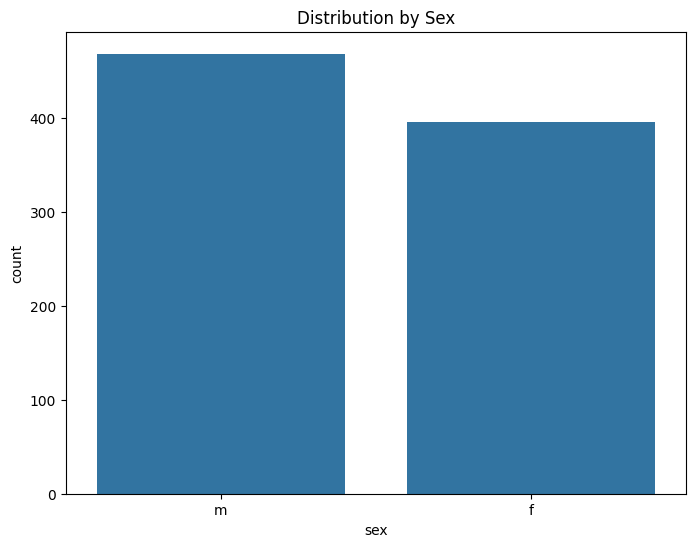

In [50]:
#sex disparity
#convert all values to lowercase
bird_df.sex = bird_df.sex.str.lower()

plt.figure(figsize=(8, 6))
sns.countplot(x='sex', data=bird_df)
plt.title('Distribution by Sex')
print(f'Difference in count:{bird_df.sex.value_counts()[0] - bird_df.sex.value_counts()[1]}')
print(f'Percentage Difference: {(bird_df.sex.value_counts()[0] - bird_df.sex.value_counts()[1]) / (bird_df.sex.value_counts()[0] + bird_df.sex.value_counts()[1]) * 100:.4f}%')

In [51]:
numerical_cols_only_df = bird_df.drop(columns=['Order', 'Genus', 'species', 'Specimen number (YPM)', 'sex', 'mass (g)'])
num_cols_list = numerical_cols_only_df.columns.tolist()
print(num_cols_list)

['femur_circumference (mm)', 'femur_diamter (mm)', 'femur_length (mm)', 'humerus_diameter (mm)', 'humerus_length (mm)', 'tarsus_circumference (mm)', 'tarsus_diameter (mm)', 'tarsus_length (mm)', 'tibia_length (mm)', 'humerus_circumference (mm)', 'coracoid HAF (mm)', 'coracoid shaft width', 'coracoid max length']


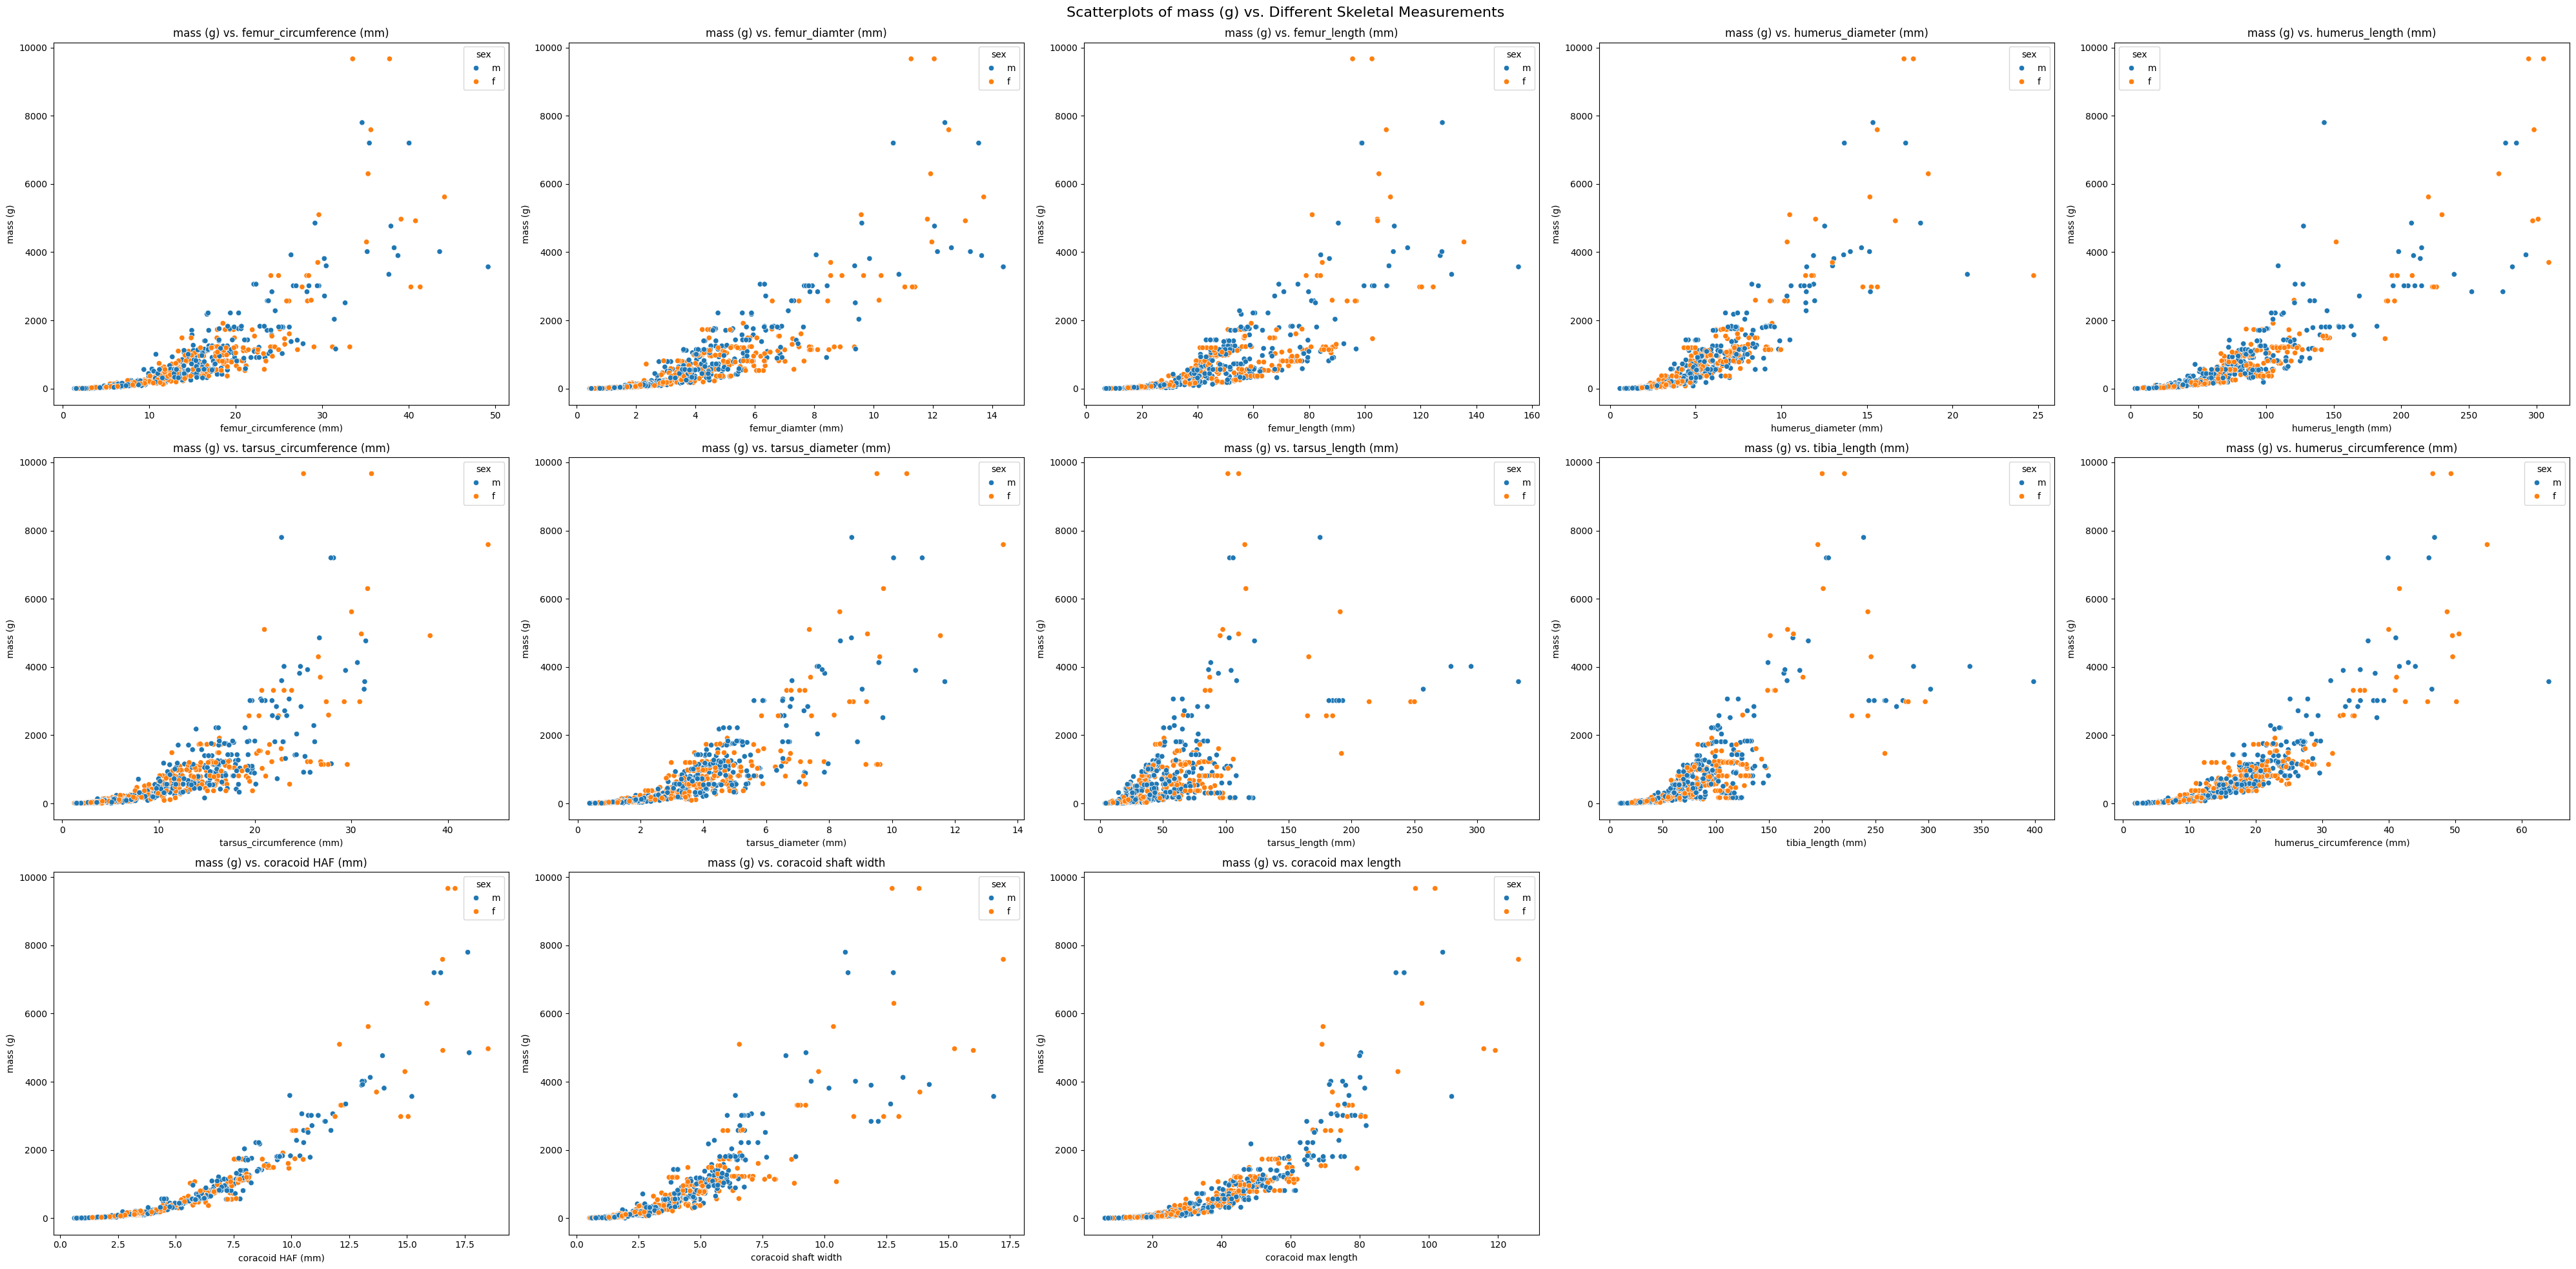

In [52]:
#scatterplot of mass (g) vs. each of the numerical columns
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(40, 20))
fig.suptitle('Scatterplots of mass (g) vs. Different Skeletal Measurements \n', fontsize=16)
axes = axes.flatten()
for i, (col, ax) in enumerate(zip(num_cols_list, axes)):
    sns.scatterplot(x=bird_df[col], y=bird_df['mass (g)'], ax=ax, hue=bird_df['sex'])
    ax.set_title(f'mass (g) vs. {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('mass (g)')

# Hide the unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout() 

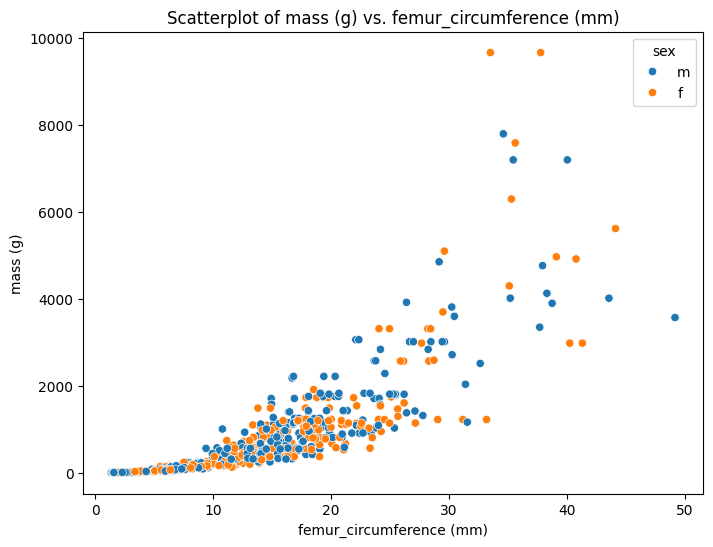

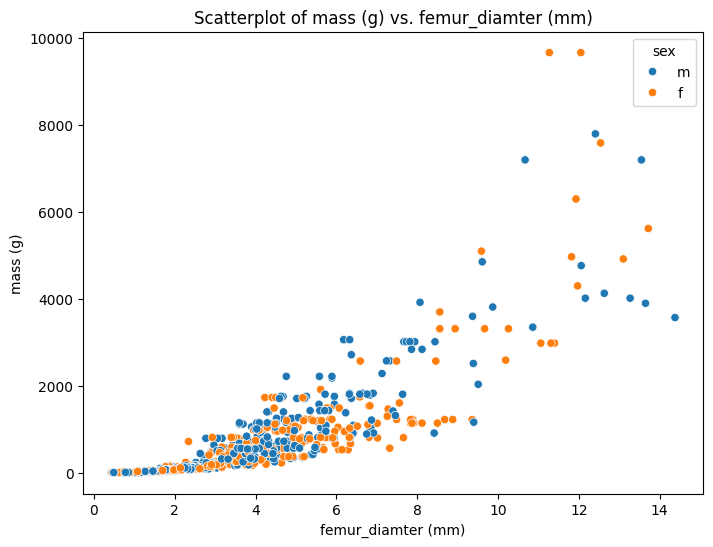

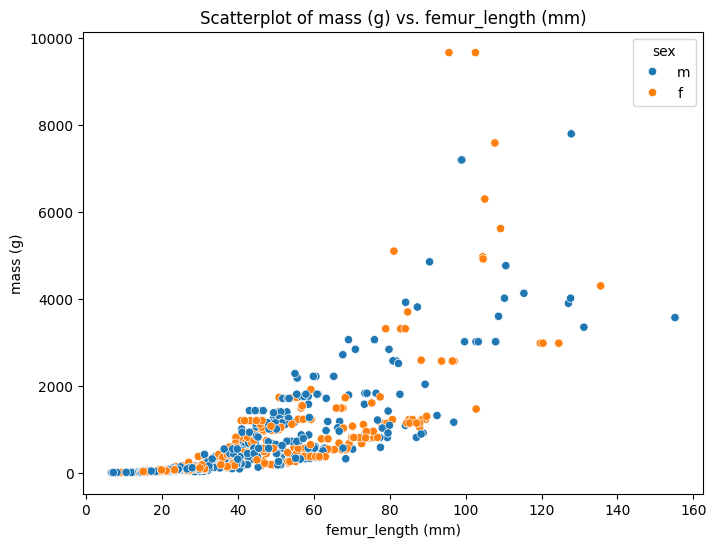

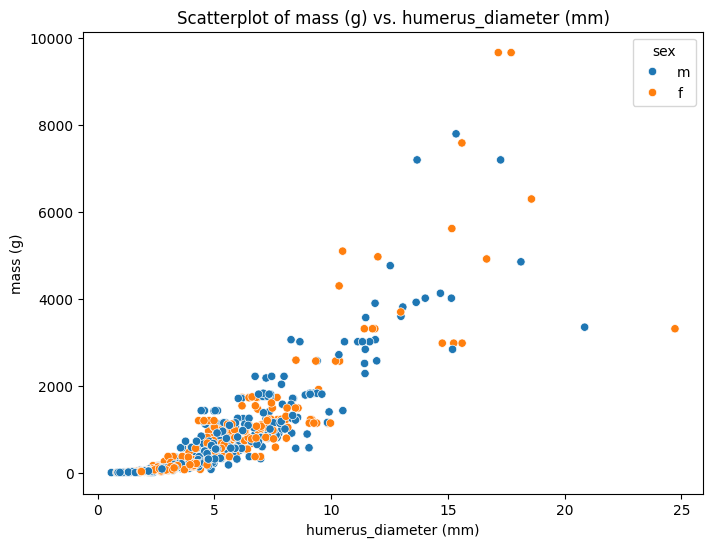

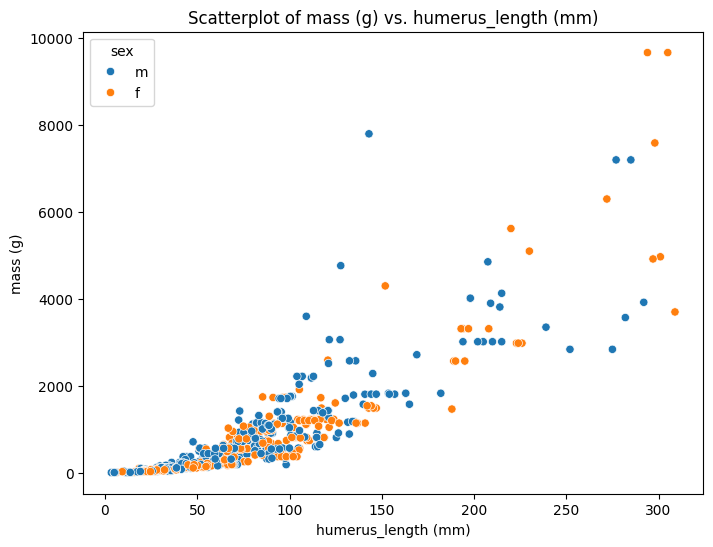

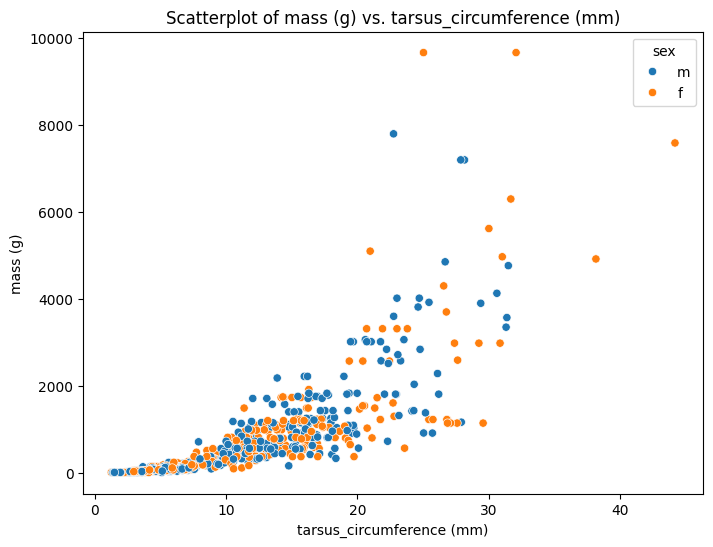

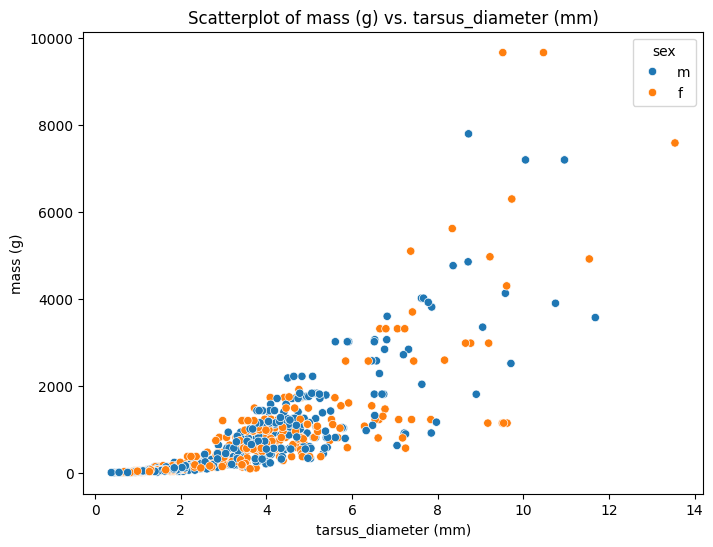

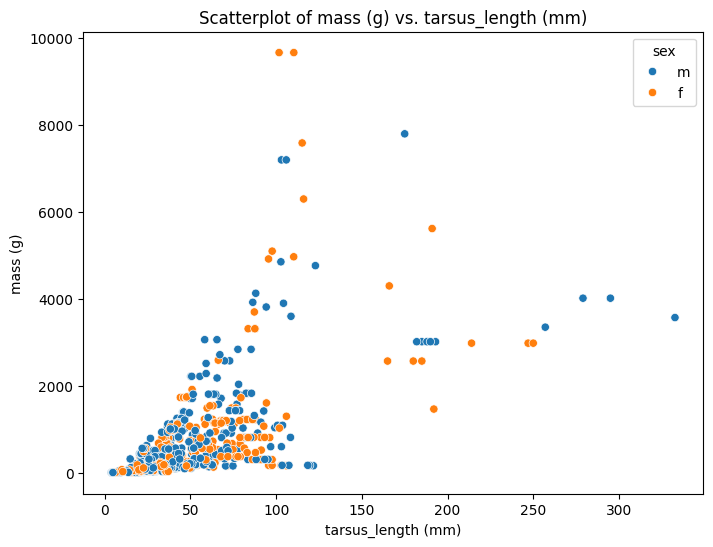

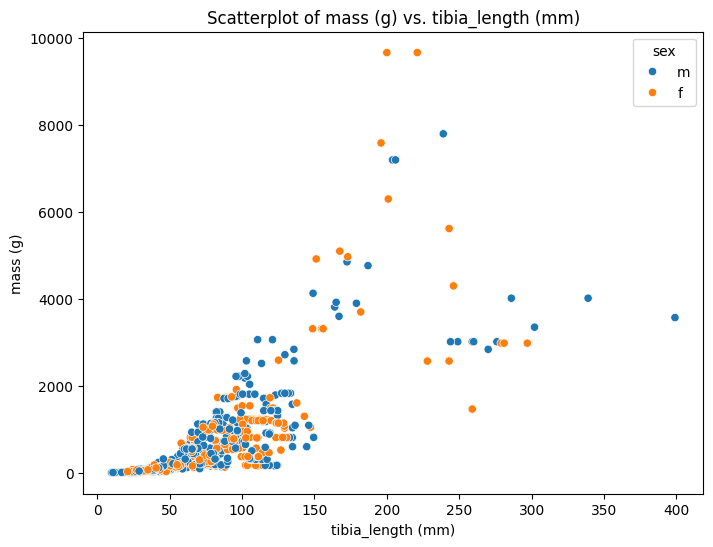

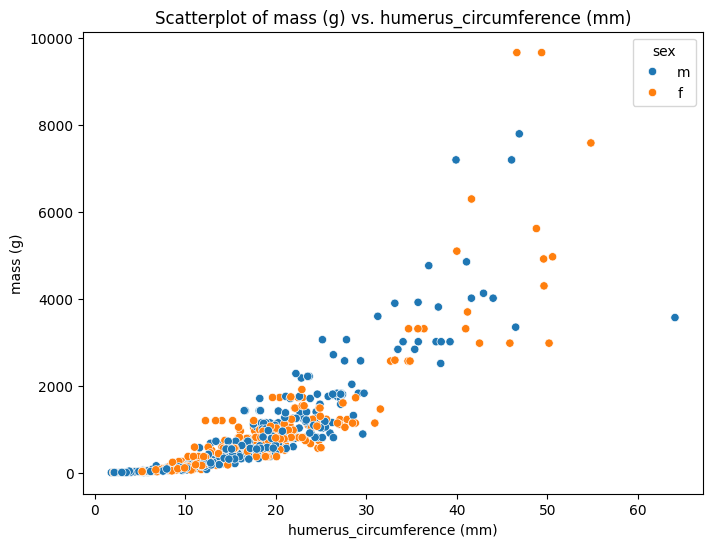

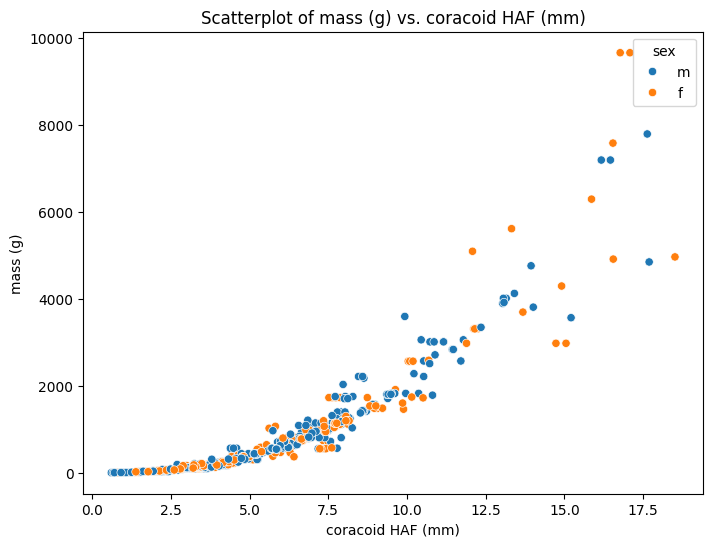

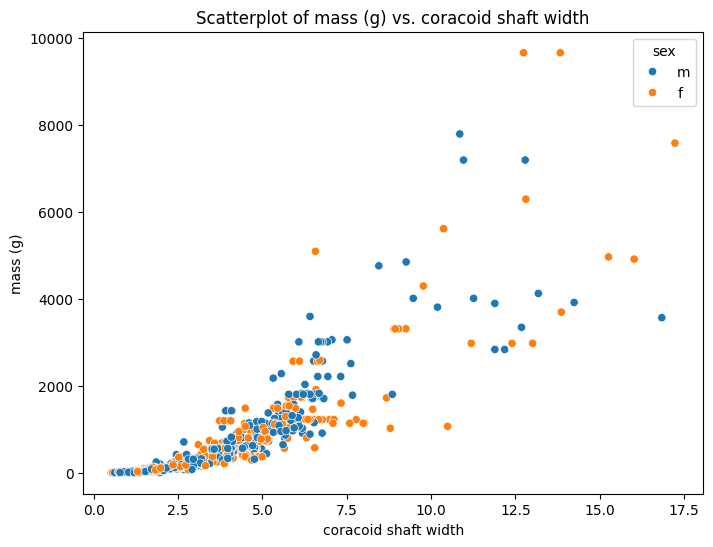

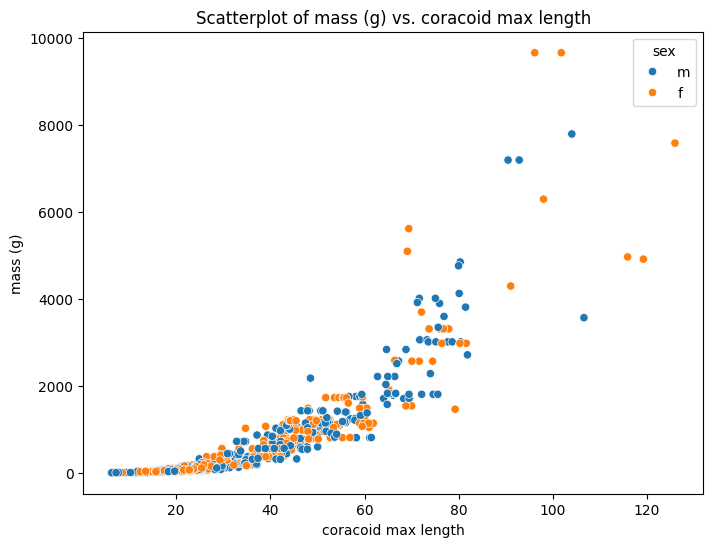

In [53]:
for col in num_cols_list:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=bird_df[col], y=bird_df['mass (g)'], hue=bird_df.sex)
    plt.title(f'Scatterplot of mass (g) vs. {col}')
    plt.xlabel(col)
    plt.ylabel('mass (g)')
    plt.show()

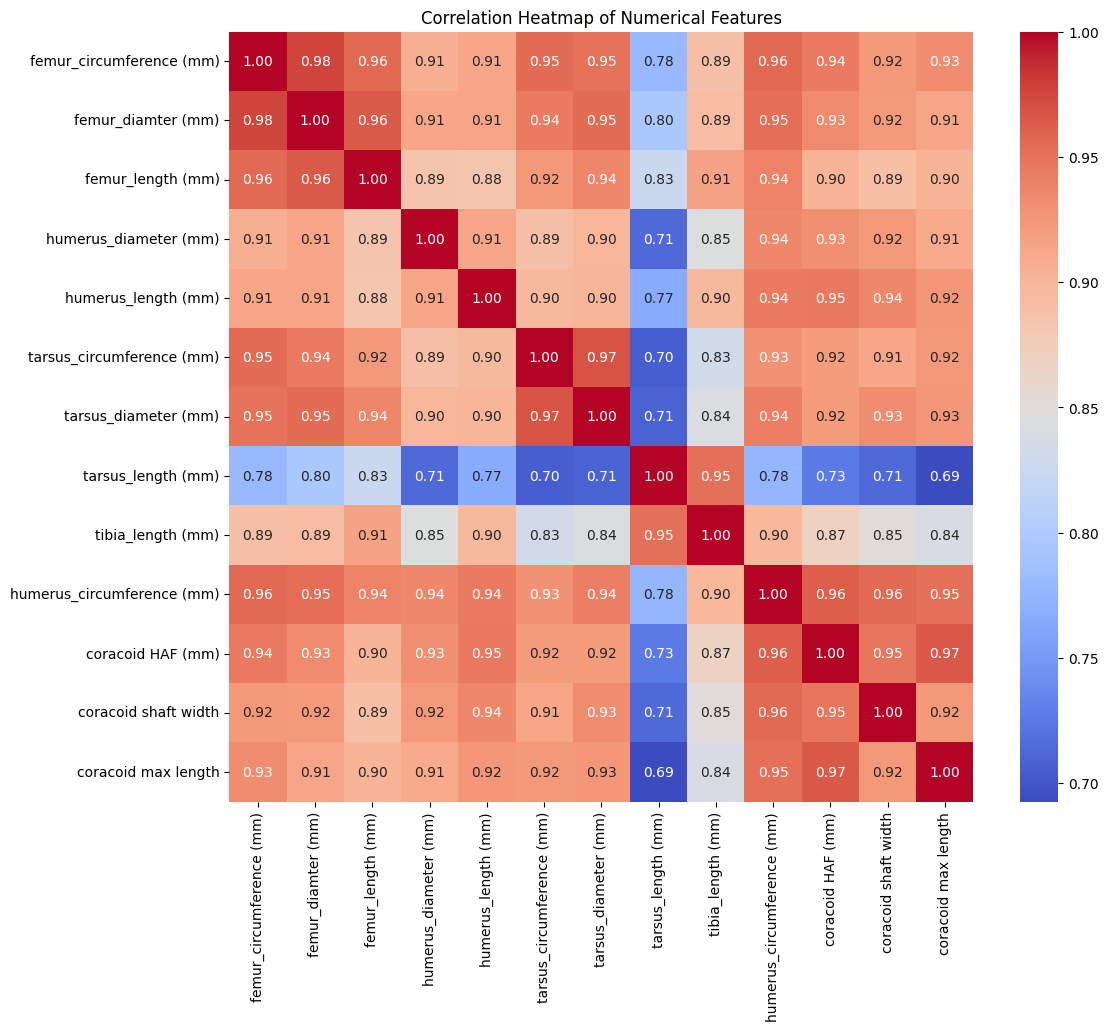

In [54]:
#correlation heat map
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_cols_only_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(numerical_cols_only_df.values, i) for i in range(len(numerical_cols_only_df.columns))]
vif['Variable'] = numerical_cols_only_df.columns
vif.sort_values(by='VIF', ascending=False)

,VIF,Variable
8,161.969545,tibia_length (mm)
1,121.620362,femur_diamter (mm)
0,102.162247,femur_circumference (mm)
9,95.370493,humerus_circumference (mm)
10,92.683277,coracoid HAF (mm)
2,90.551310,femur_length (mm)
6,84.451531,tarsus_diameter (mm)
5,64.377255,tarsus_circumference (mm)
7,62.110231,tarsus_length (mm)
12,60.552997,coracoid max length


In [56]:
# Identify problematic variables
high_vif = vif[vif['VIF'] > 5]
if not high_vif.empty:
    print(f"\nVariables with elevated VIF (> 5):")
    for _, row in high_vif.iterrows():
        print(f"  {row['Variable']}: {row['VIF']:.3f}")
else:
    print(f"\nNo concerning multicollinearity detected (all VIF < 5)")


Variables with elevated VIF (> 5):
  femur_circumference (mm): 102.162
  femur_diamter (mm): 121.620
  femur_length (mm): 90.551
  humerus_diameter (mm): 29.944
  humerus_length (mm): 39.529
  tarsus_circumference (mm): 64.377
  tarsus_diameter (mm): 84.452
  tarsus_length (mm): 62.110
  tibia_length (mm): 161.970
  humerus_circumference (mm): 95.370
  coracoid HAF (mm): 92.683
  coracoid shaft width: 46.683
  coracoid max length: 60.553


#### **Log Transformation**

For analysis, the natural log (ln) of all measurements including mass are taken to mitigate the effects of extreme outliers on the coefficients and to make the data more suitable for a linear model. 

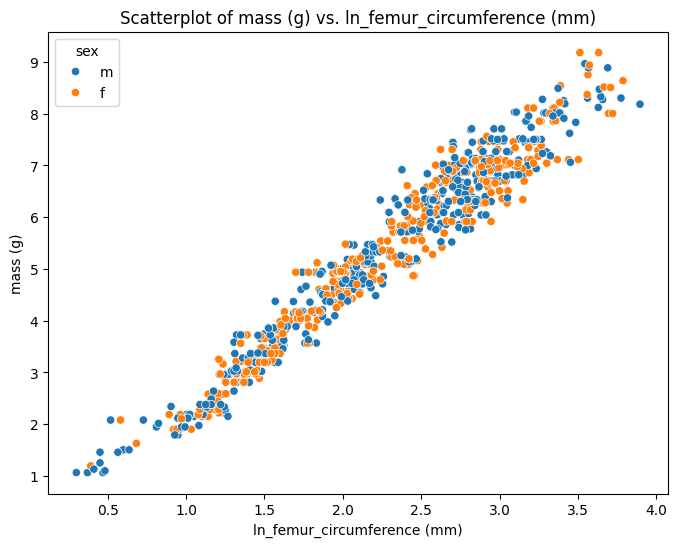

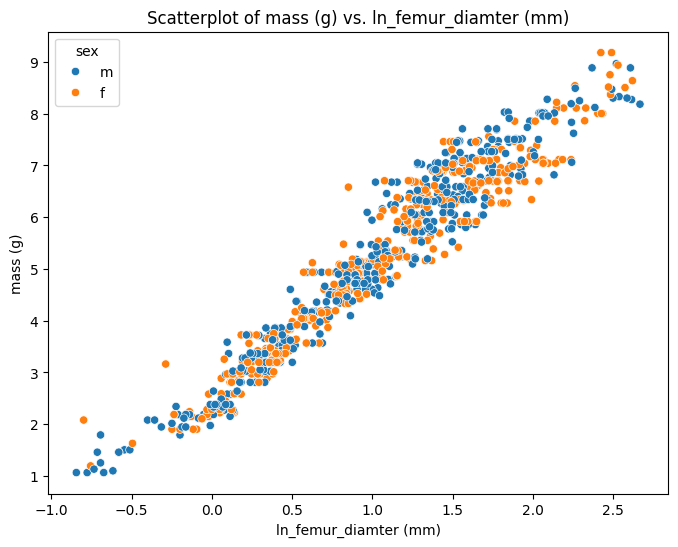

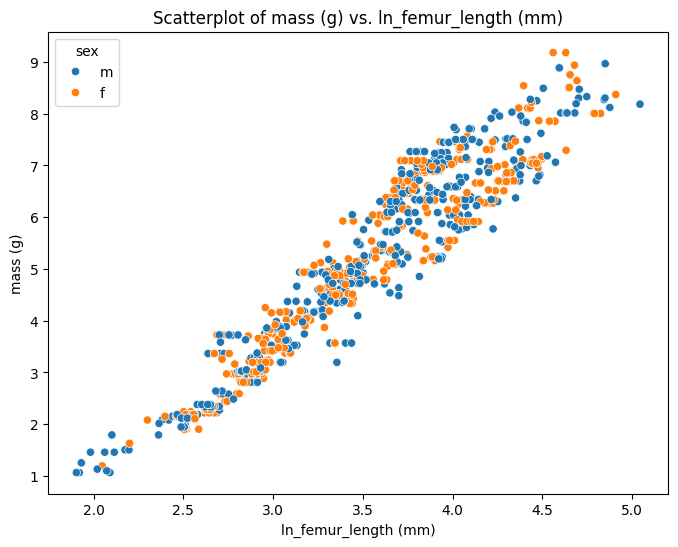

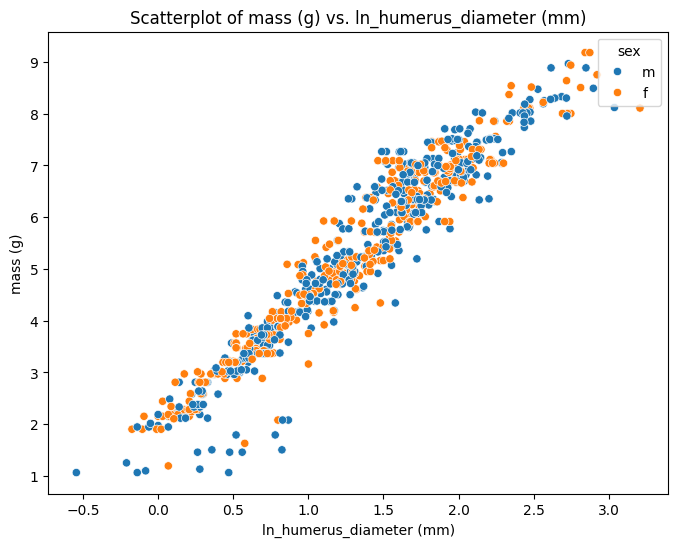

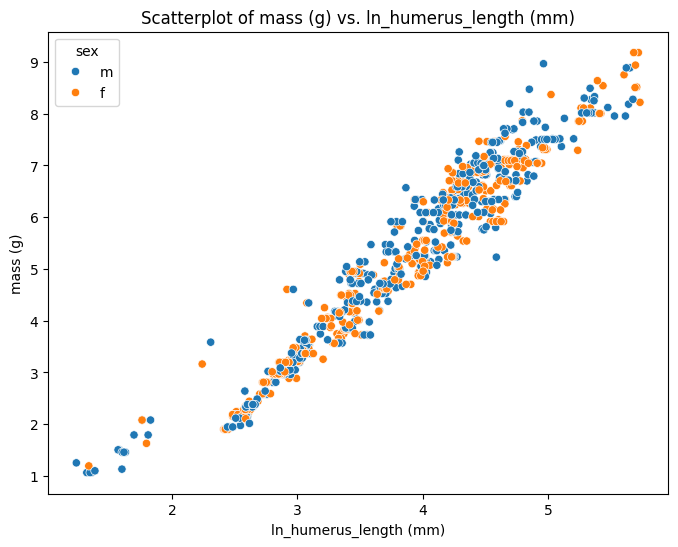

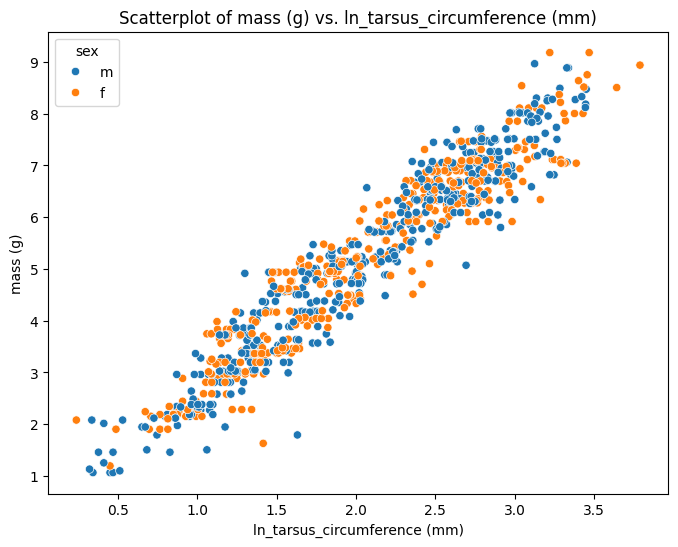

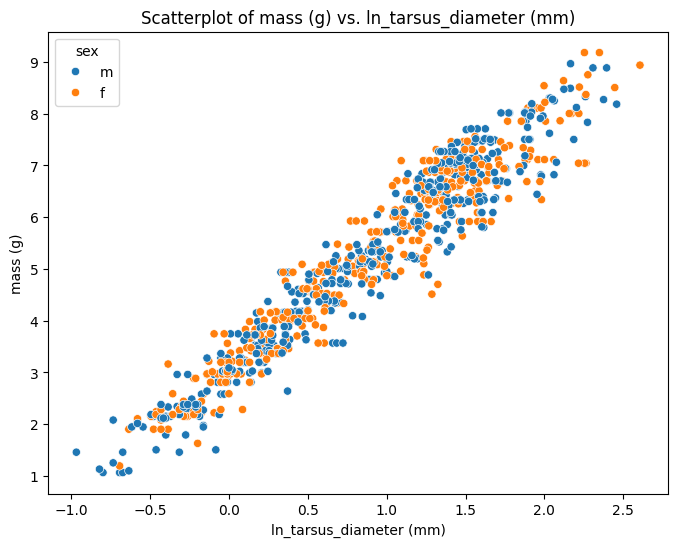

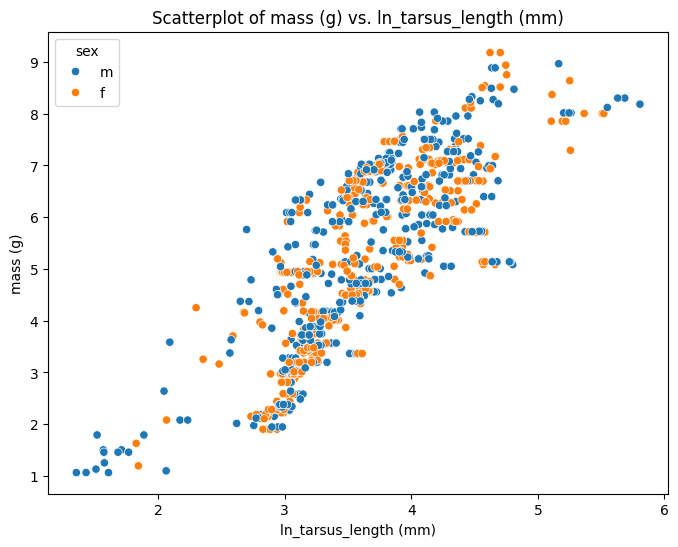

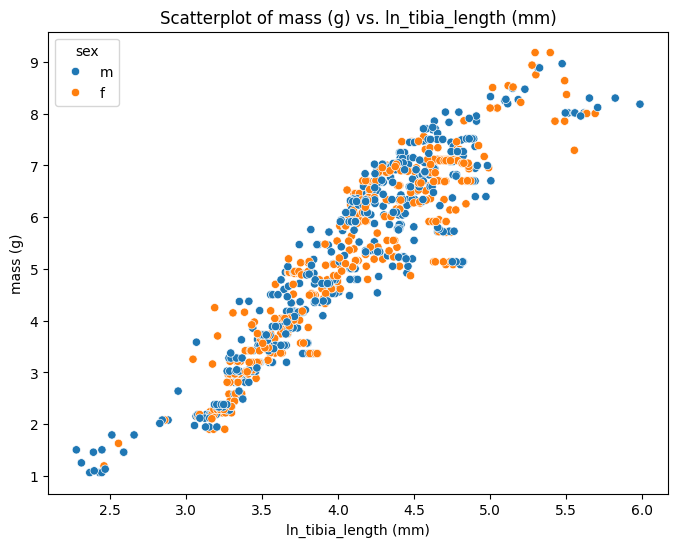

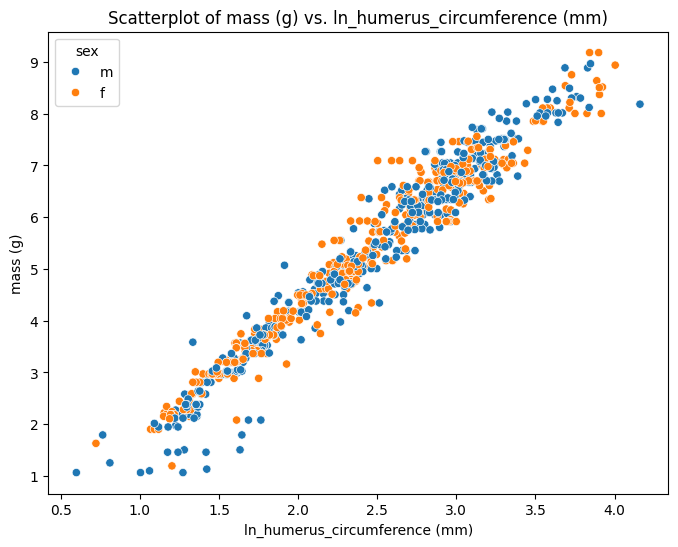

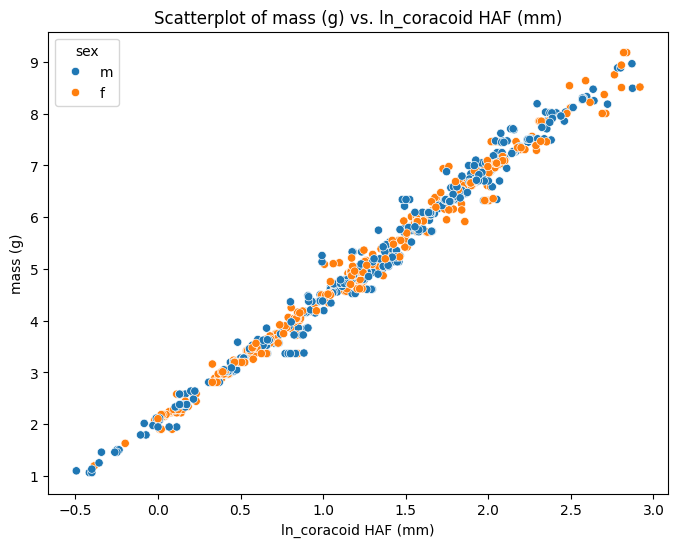

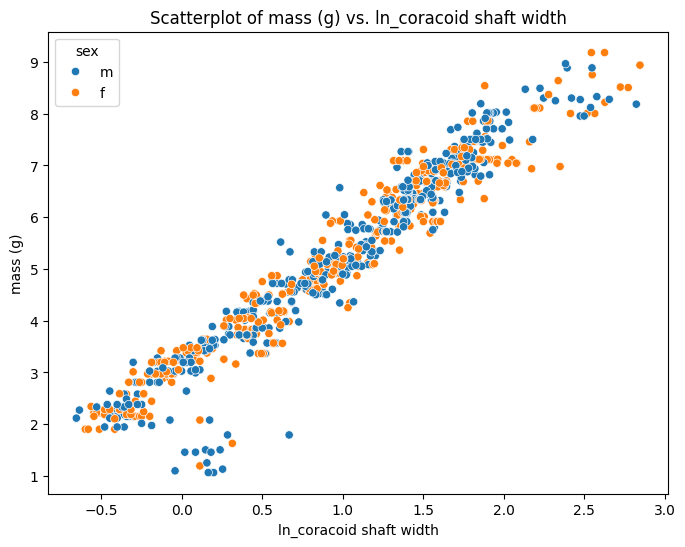

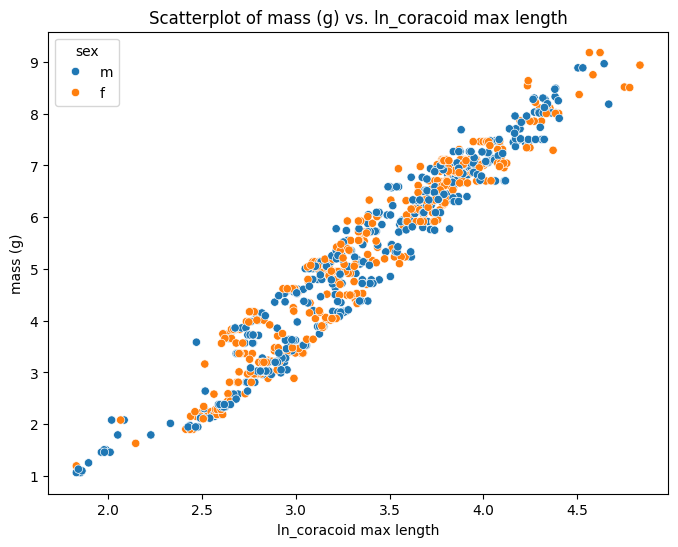

In [57]:
ln_df = numerical_cols_only_df.apply(np.log)
ln_col_names = ln_df.columns.tolist()

#Add "ln" to each column name to indicate that it's the log-transformed version
for i in range(len(ln_col_names)):
    ln_col_names[i] = "ln_" + ln_col_names[i]

ln_df.columns = ln_col_names
ln_df.columns


for col in ln_col_names:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=ln_df[col], y=bird_df['mass (g)'].apply(np.log), hue=bird_df.sex)
    plt.title(f'Scatterplot of mass (g) vs. {col}')
    plt.xlabel(col)
    plt.ylabel('mass (g)')
    plt.show()

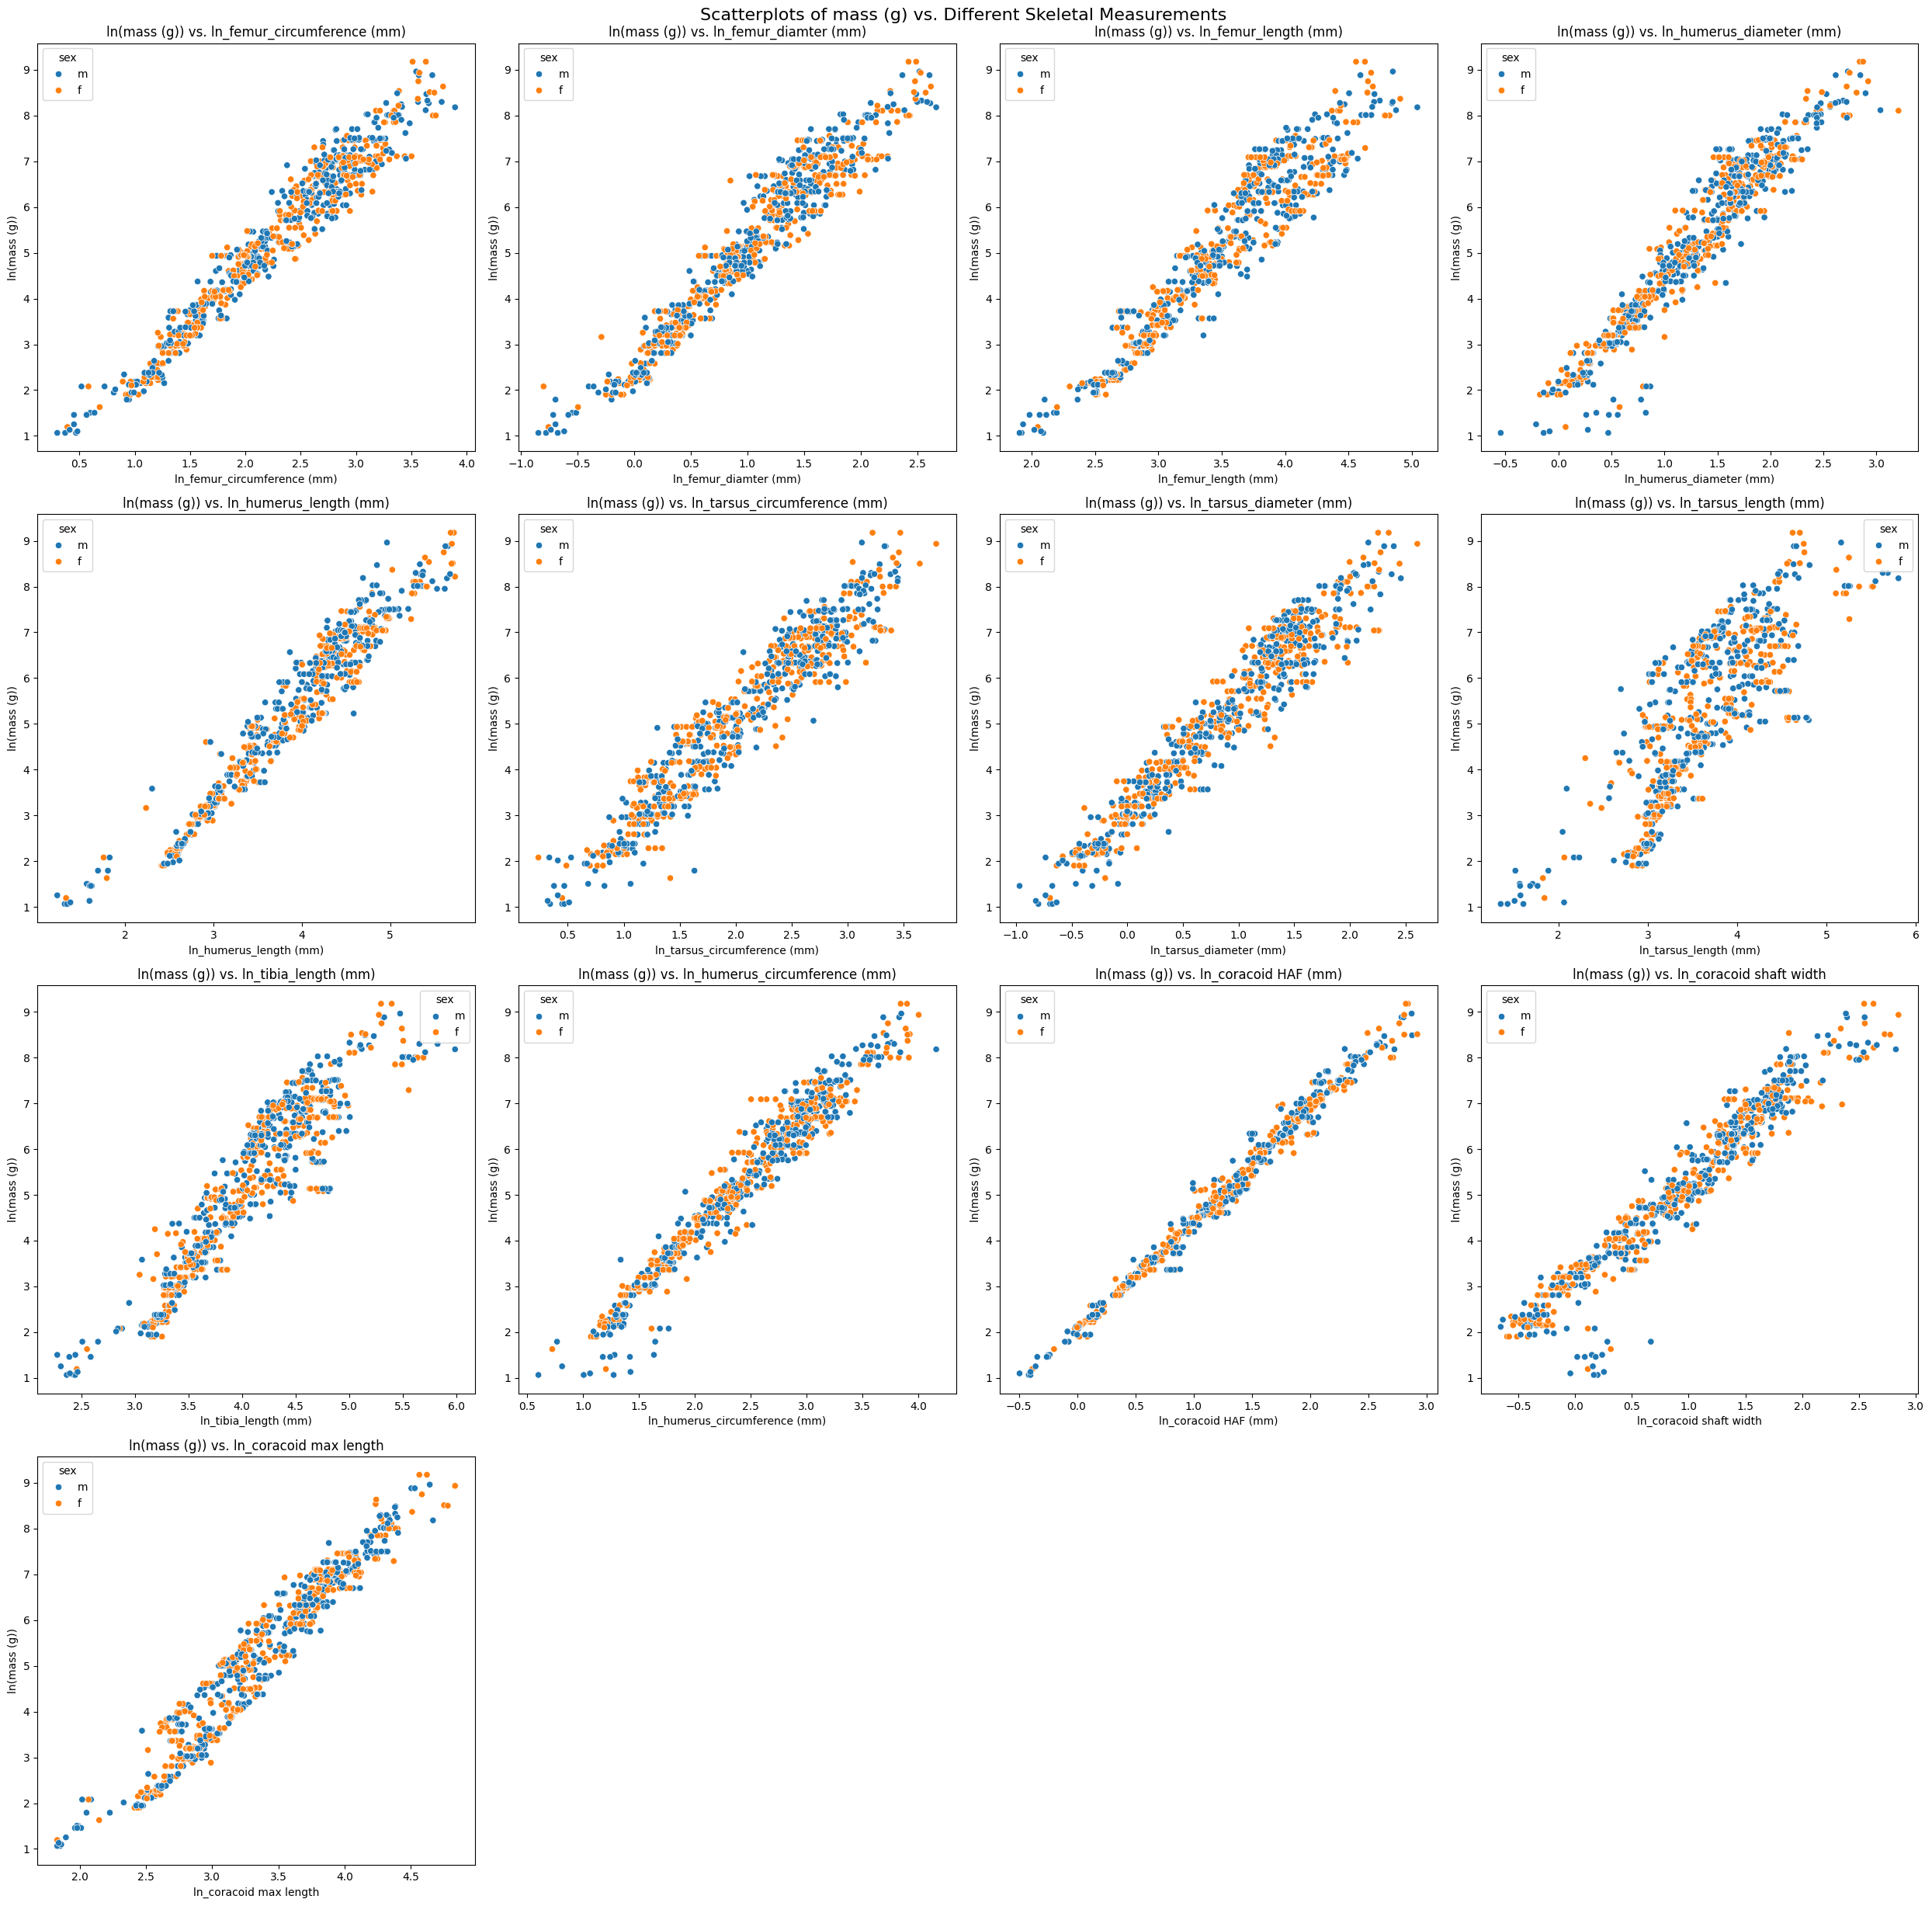

In [58]:
#scatterplot of ln(mass (g)) vs. each of the numerical columns
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(25, 25))
fig.suptitle('Scatterplots of mass (g) vs. Different Skeletal Measurements \n', fontsize=16)
axes = axes.flatten()
for i, (col, ax) in enumerate(zip(ln_col_names, axes)):
    sns.scatterplot(x=ln_df[col], y=bird_df['mass (g)'].apply(np.log), ax=ax, hue=bird_df.sex)
    ax.set_title(f'ln(mass (g)) vs. {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('ln(mass (g))')

# Hide the unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout() # Recommended to prevent titles overlapping

#### **Correlation Heat Map** 

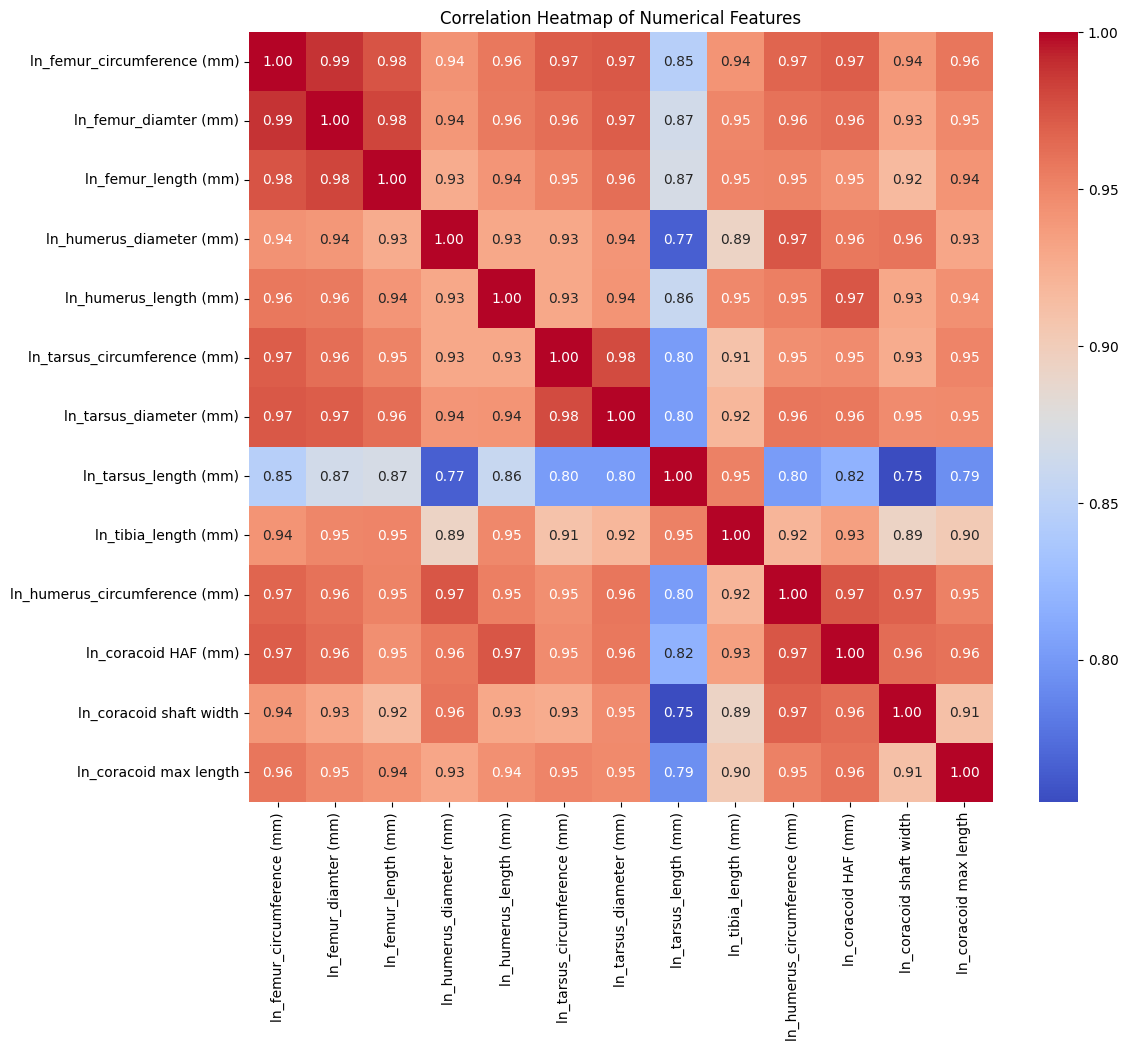

In [59]:
#correlation heat map
plt.figure(figsize=(12, 10))
sns.heatmap(ln_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#### **2. OLS Implementation for each measurement**

The first implementation generates a univariate linear regression for all measurements to mass (natural log taken for all measurements and mass), with the R^2 score being the coefficient of determination; a higher R^2 implies that the skeletal measurement explains the variance of the mass better or that the skeletal measurement better correlates with mass. The MSE, MAE, RMSE are also taken for each measurement

In [60]:
#using sklearn
lm = LinearRegression()
for i in ln_col_names:
    X = ln_df[[i]]
    y = bird_df['mass (g)'].apply(np.log)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    lm.fit(X_train, y_train)
    y_pred = lm.predict(X_test)
    print(f"Results for {i}:")
    print(f"  R-squared: {r2_score(y_test, y_pred):.4f}")
    print(f"  MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"  MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}\n")

Results for ln_femur_circumference (mm):
  R-squared: 0.9564
  MSE: 0.1478
  MAE: 0.3056
  RMSE: 0.3844

Results for ln_femur_diamter (mm):
  R-squared: 0.9422
  MSE: 0.1962
  MAE: 0.3521
  RMSE: 0.4430

Results for ln_femur_length (mm):
  R-squared: 0.9237
  MSE: 0.2587
  MAE: 0.4194
  RMSE: 0.5087

Results for ln_humerus_diameter (mm):
  R-squared: 0.9486
  MSE: 0.1745
  MAE: 0.2975
  RMSE: 0.4177

Results for ln_humerus_length (mm):
  R-squared: 0.9496
  MSE: 0.1712
  MAE: 0.3420
  RMSE: 0.4137

Results for ln_tarsus_circumference (mm):
  R-squared: 0.9091
  MSE: 0.3084
  MAE: 0.4486
  RMSE: 0.5554

Results for ln_tarsus_diameter (mm):
  R-squared: 0.9359
  MSE: 0.2176
  MAE: 0.3668
  RMSE: 0.4665

Results for ln_tarsus_length (mm):
  R-squared: 0.7037
  MSE: 1.0054
  MAE: 0.8871
  RMSE: 1.0027

Results for ln_tibia_length (mm):
  R-squared: 0.8907
  MSE: 0.3709
  MAE: 0.5113
  RMSE: 0.6090

Results for ln_humerus_circumference (mm):
  R-squared: 0.9693
  MSE: 0.1040
  MAE: 0.2245
 

##### **StatsModels OLS**

In [61]:
#using statsmodels, for each measurement
for i in ln_col_names:
    X = sm.add_constant(ln_df[i])  # Add constant term for intercept
    y = bird_df['mass (g)'].apply(np.log)
    model = sm.OLS(y, X).fit()
    print(f"Results for {i}:")
    print(model.summary())

Results for ln_femur_circumference (mm):
                            OLS Regression Results                            
Dep. Variable:               mass (g)   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                 1.738e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:49:47   Log-Likelihood:                -407.56
No. Observations:                 863   AIC:                             819.1
Df Residuals:                     861   BIC:                             828.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [62]:
#retrieve the R^2 for each model
for i in ln_col_names:
    X = sm.add_constant(ln_df[i]) 
    y = bird_df['mass (g)'].apply(np.log)
    model = sm.OLS(y, X).fit()
    print(f"R-squared for {i}: {model.rsquared:.4f}")

R-squared for ln_femur_circumference (mm): 0.9528
R-squared for ln_femur_diamter (mm): 0.9320
R-squared for ln_femur_length (mm): 0.9029
R-squared for ln_humerus_diameter (mm): 0.9265
R-squared for ln_humerus_length (mm): 0.9364
R-squared for ln_tarsus_circumference (mm): 0.9146
R-squared for ln_tarsus_diameter (mm): 0.9263
R-squared for ln_tarsus_length (mm): 0.6463
R-squared for ln_tibia_length (mm): 0.8580
R-squared for ln_humerus_circumference (mm): 0.9549
R-squared for ln_coracoid HAF (mm): 0.9881
R-squared for ln_coracoid shaft width: 0.9285
R-squared for ln_coracoid max length: 0.9357


#### **3. Multivariate linear regression using least squares**

First, we need for check for variance inflation. From the EDA part, the correlation heat map shows multiple skeletal measurements correlated with one another. This violates an assumption of Ordinary Least Squares regression where all features must be independent. Nonetheless, we check for problematic features using the variance inflaction factor.

In [63]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(ln_df.values, i) for i in range(len(ln_df.columns))]
vif['Variable'] = ln_df.columns
print(vif.sort_values(by='VIF', ascending=False))

print("\nAll features are problematic due to their variance inflation factors being above 5, indicating severe multicollinearity. \nThis suggests that the features are highly correlated with each other, which can lead to unreliable coefficient estimates")

            VIF                       Variable
8   2378.842806           ln_tibia_length (mm)
2   1127.065158           ln_femur_length (mm)
7    732.806717          ln_tarsus_length (mm)
12   720.860781         ln_coracoid max length
0    714.913221    ln_femur_circumference (mm)
9    613.978780  ln_humerus_circumference (mm)
4    560.964643         ln_humerus_length (mm)
5    288.583987   ln_tarsus_circumference (mm)
10   204.858344           ln_coracoid HAF (mm)
1    186.012160          ln_femur_diamter (mm)
3    105.825774       ln_humerus_diameter (mm)
6     95.837043        ln_tarsus_diameter (mm)
11    74.267265        ln_coracoid shaft width

All features are problematic due to their variance inflation factors being above 5, indicating severe multicollinearity. 
This suggests that the features are highly correlated with each other, which can lead to unreliable coefficient estimates


To address this, we use ridge regression with cross validation to shrink the coefficients without allowing any of them to reach zero since we need all features. 

#### **L2 Penalty Implementation**

In [64]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=kf)
X = ln_df
y = bird_df['mass (g)'].apply(np.log)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge.fit(X_train_scaled, y_train)
y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

print(f"R-squared: {r2_score(y_test, y_test_pred):.4f}")
print(f"Adjusted R-squared: {1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_test_pred):.4f}")
print(f"\nCoefficients (Standardized):")
for col, coef in zip(ln_df.columns, ridge.coef_):
    print(f"  {col}: {coef:.4f}")

R-squared: 0.9942
Adjusted R-squared: 0.9937
MSE: 0.0197
MAE: 0.0992
MAPE: 0.0215

Coefficients (Standardized):
  ln_femur_circumference (mm): 0.2469
  ln_femur_diamter (mm): -0.0356
  ln_femur_length (mm): 0.0888
  ln_humerus_diameter (mm): 0.0845
  ln_humerus_length (mm): 0.0125
  ln_tarsus_circumference (mm): 0.1485
  ln_tarsus_diameter (mm): -0.1903
  ln_tarsus_length (mm): -0.2030
  ln_tibia_length (mm): 0.1557
  ln_humerus_circumference (mm): -0.0120
  ln_coracoid HAF (mm): 1.2024
  ln_coracoid shaft width: 0.0715
  ln_coracoid max length: 0.1872


#### **Coefficients**

In [65]:
for col, coef in zip(ln_df.columns, ridge.coef_):
    print(f"  {col[3:]}: {np.exp(coef):.4f}")

  femur_circumference (mm): 1.2801
  femur_diamter (mm): 0.9650
  femur_length (mm): 1.0928
  humerus_diameter (mm): 1.0881
  humerus_length (mm): 1.0126
  tarsus_circumference (mm): 1.1601
  tarsus_diameter (mm): 0.8267
  tarsus_length (mm): 0.8163
  tibia_length (mm): 1.1685
  humerus_circumference (mm): 0.9881
  coracoid HAF (mm): 3.3281
  coracoid shaft width: 1.0742
  coracoid max length: 1.2059


#### **Exponentiated Coefficients**

In [66]:
for col, coef in zip(ln_df.columns, ridge.coef_):
    print(f"  {col[3:]}: {abs(1-np.exp(coef))*100:.4f}")

  femur_circumference (mm): 28.0083
  femur_diamter (mm): 3.5001
  femur_length (mm): 9.2848
  humerus_diameter (mm): 8.8134
  humerus_length (mm): 1.2596
  tarsus_circumference (mm): 16.0084
  tarsus_diameter (mm): 17.3325
  tarsus_length (mm): 18.3727
  tibia_length (mm): 16.8485
  humerus_circumference (mm): 1.1944
  coracoid HAF (mm): 232.8130
  coracoid shaft width: 7.4161
  coracoid max length: 20.5913


#### **Percent Change of Mass for a One Standard Deviation Increase in a Measurement (all else constant)**

In [67]:
for col, coef in zip(ln_df.columns, ridge.coef_):
    print(f"  {col[3:]}: {(np.exp(coef)-1)*100:.4f}")

  femur_circumference (mm): 28.0083
  femur_diamter (mm): -3.5001
  femur_length (mm): 9.2848
  humerus_diameter (mm): 8.8134
  humerus_length (mm): 1.2596
  tarsus_circumference (mm): 16.0084
  tarsus_diameter (mm): -17.3325
  tarsus_length (mm): -18.3727
  tibia_length (mm): 16.8485
  humerus_circumference (mm): -1.1944
  coracoid HAF (mm): 232.8130
  coracoid shaft width: 7.4161
  coracoid max length: 20.5913


#### **Ridge Traceplot using K-Fold Cross Validation**

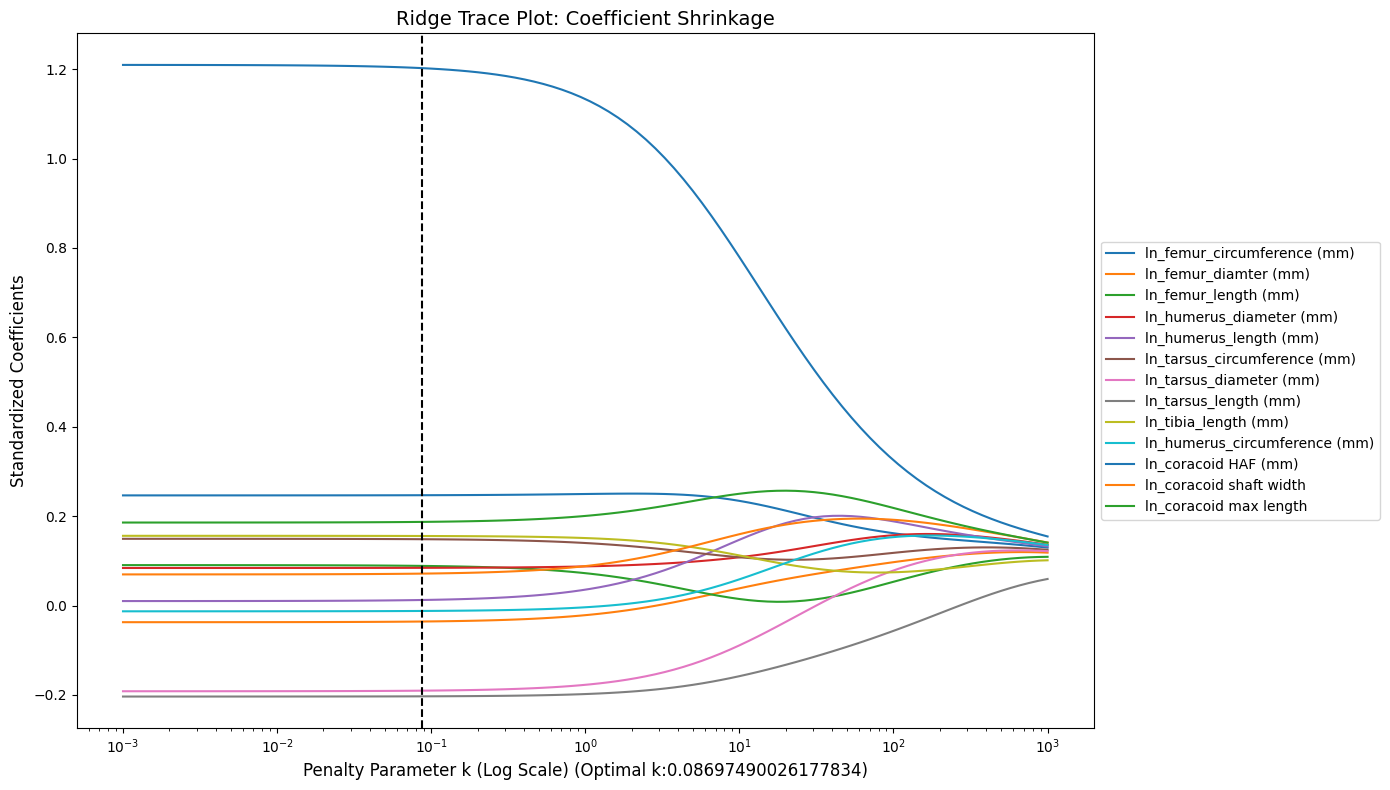

Optimal k (lambda): 0.0870


In [68]:
#in this example, lambda and k are the same. note that for sklearn, lambda and k are called "alpha" (refer to the documentation on sklearn.linear_model.Ridge class)
k_values = np.logspace(-3, 3, 100)
coefs = []

for k in k_values:
    ridge_trace_model = Ridge(alpha=k)
    ridge_trace_model.fit(X_train_scaled, y_train)
    coefs.append(ridge_trace_model.coef_)

plt.figure(figsize=(14, 8))
ax = plt.gca()

# Plot the coefficients against the k values
lines = ax.plot(k_values, coefs)
plt.xscale('log') # The x-axis must be logarithmic

# 4. Formatting and Labels
plt.xlabel(f'Penalty Parameter k (Log Scale) (Optimal k:{ridge.alpha_})', fontsize=12)
plt.ylabel('Standardized Coefficients', fontsize=12)
plt.title('Ridge Trace Plot: Coefficient Shrinkage', fontsize=14)

# Vertical line for optimal lambda
plt.axvline(x=ridge.alpha_, linestyle='--', color='black', label=f'Optimal k ({ridge.alpha_:.4f})')
plt.legend(lines, ln_df.columns, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

print(f"Optimal k (lambda): {ridge.alpha_:.4f}")

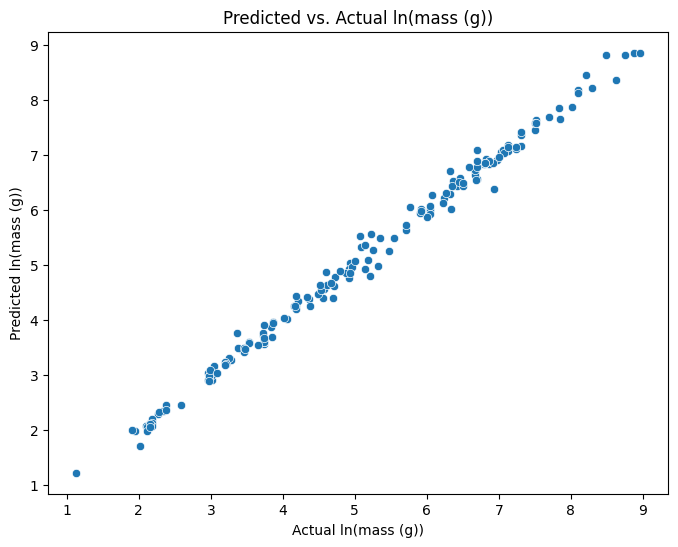

In [69]:
#plotting the predicted vs actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel('Actual ln(mass (g))')
plt.ylabel('Predicted ln(mass (g))')
plt.title('Predicted vs. Actual ln(mass (g))')
plt.show()

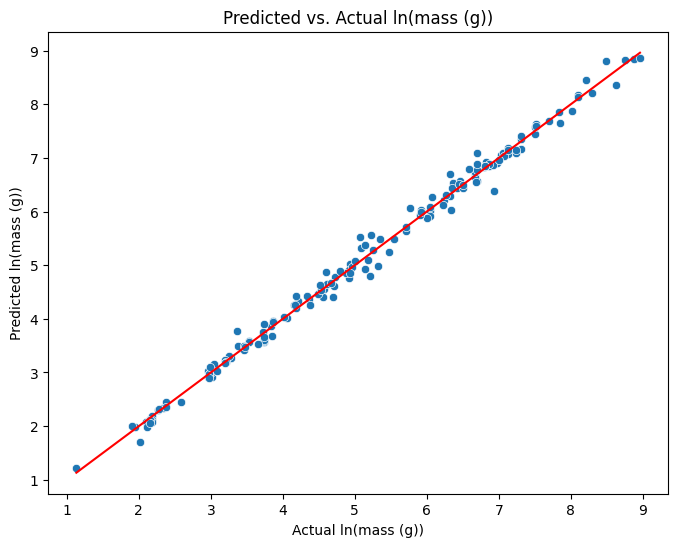

In [70]:
#graphing the equation of the model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual ln(mass (g))')
plt.ylabel('Predicted ln(mass (g))')
plt.title('Predicted vs. Actual ln(mass (g))')
plt.show()

#### **Training and Testing Scores**

In [73]:
scores = pd.DataFrame()
scores['Metric'] = ['R-squared', 'Adjusted R-squared', 'MSE', 'MAE', 'MAPE']
scores['Training Score'] = [r2_score(y_train, y_train_pred), 1 - (1 - r2_score(y_train, y_train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train_scaled.shape[1] - 1), mean_squared_error(y_train, y_train_pred), mean_absolute_error(y_train, y_train_pred), mean_absolute_percentage_error(y_train, y_train_pred)]
scores['Testing Score'] = [r2_score(y_test, y_test_pred), 1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1), mean_squared_error(y_test, y_test_pred), mean_absolute_error(y_test, y_test_pred), mean_absolute_percentage_error(y_test, y_test_pred)]
print(scores.to_string(index=False))

            Metric  Training Score  Testing Score
         R-squared        0.992636       0.994194
Adjusted R-squared        0.992494       0.993720
               MSE        0.023102       0.019698
               MAE        0.106689       0.099234
              MAPE        0.022445       0.021466
